## Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

## **Initialisation**


In [ ]:
# --- DÉBUT de apprentissage.py ---
vins = pd.read_csv("../data/wine_clean.csv")
print("Charge here we go mon coco!")

Chargé here we go mon coco!


### Question 15 - Préparation des données
On sépare les données en **75% entraînement** et **25% test**.
random_state=49 fixe le hasard pour la reproductibilité, c'est la seed en gros.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    # Tous sauf le prix
    vins.drop(columns=["Prix"]), vins['Prix'], train_size=0.75, random_state=49
)
print(f"Train size : {X_train.shape}")
print(f"Test size : {X_test.shape}")

Train size : (2087, 30)
Test size : (696, 30)


## **Premier modèle : Régression Linéaire**

### Question 16 - Score R^2
Interet : Mesurer la quality du modele. Le R^2 vaut :

- 1.0 → predictions nickel 
- 0.0 → le modele ne fait pas mieux que de predire la moyenne
- < 0 → le modele est pire que de peedire la moyenne



In [7]:
model_lR = LinearRegression()
model_lR.fit(X_train, y_train)
y_pred = model_lR.predict(X_test)

### Question 17 - Figure de visualisation
Interet : Le R^2 seul ne dit pas tout. La figure permet de voir visuellement si le modèle est bon :

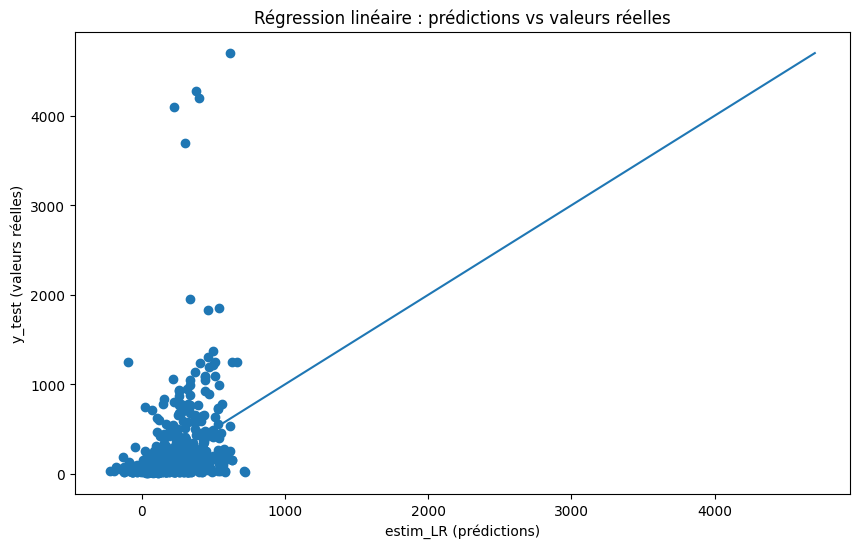

In [8]:
def afficherSchema(y_pred, y_test):
    plt.figure(figsize=(10,6))
    plt.scatter(y_pred, y_test)

    plt.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()])

    plt.xlabel("estim_LR (prédictions)")
    plt.ylabel("y_test (valeurs réelles)")
    plt.title("Régression linéaire : prédictions vs valeurs réelles")

    plt.show()

afficherSchema(y_pred ,y_test)

Constat : C'est tres moche

### Question 18 - Impact du pre-traitement
Interet : La regression lineaire peut etre sensible aux échelles des donnees. Par ex, une note sur 100 et une note sur 20 ne sont pas comparables directement

Question 18 :

r2 score (_lR_normal): 0.07200425862077287


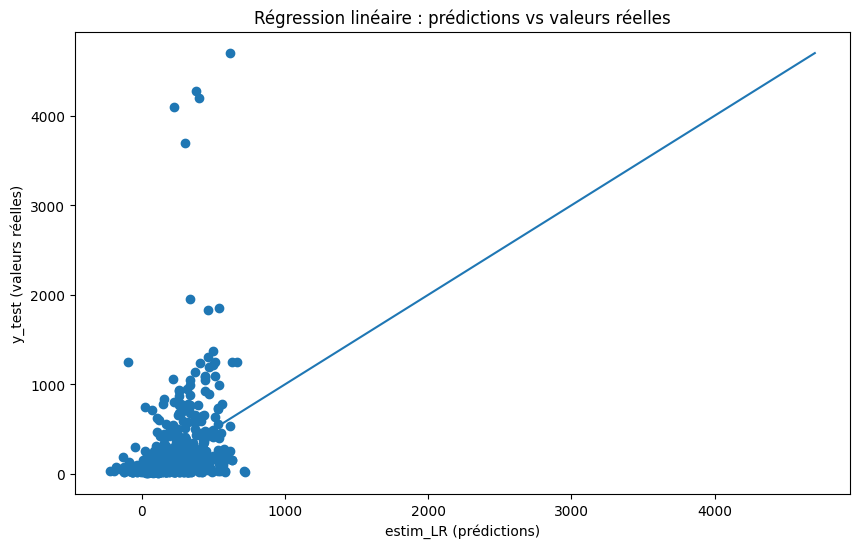

In [9]:
model_lR_normal = make_pipeline(MinMaxScaler(),  LinearRegression())
model_lR_normal.fit(X_train, y_train)
y_pred = model_lR_normal.predict(X_test)

print("Question 18 :\n")
print(f"r2 score (_lR_normal): {model_lR_normal.score(X_test, y_test)}")

afficherSchema(y_pred ,y_test)

### Question 19 - Dispersion des prix
Interet : Si un vin coute 10e et un autre 10 000e, la distribution est tres irreguliere. Le modele aura du mal a apprendre

In [10]:
print(f"Prix min : {vins['Prix'].min()}")
print(f"Prix max : {vins['Prix'].max()}\n")

# Grosse dispertion !

y_log = np.log(vins["Prix"])
print(f"Prix min (log) : {np.log(vins['Prix']).min()}")
print(f"Prix max (log) : {np.log(vins['Prix']).max()}")


Prix min : 5.42
Prix max : 23000.0

Prix min (log) : 1.6900958154515549
Prix max (log) : 10.043249494911286


### Question 20 - Tableau comparatif LR
Interet : Comparer toutes les combinaisons pour la regression lineaire et tirer des CCL

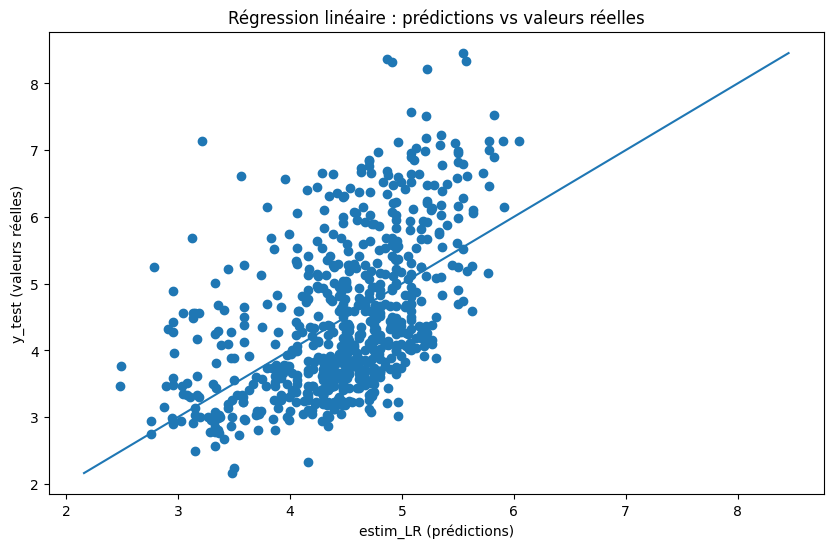

+----------------------------------------------------------+
| Méthode                    |   r²                        |
+----------------------------------------------------------+
| LR                    |    0.2767037406952396       |
| Normalisation + LR    |    0.27670374069523984       |
| Standardisation + LR  |    0.27670374069523984       |
+----------------------------------------------------------+


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    # Tous sauf le prix
    vins.drop(columns=["Prix"]), y_log, train_size=0.75, random_state=49
)

results = []
# LR
model_lR_log = LinearRegression()
model_lR_log.fit(X_train, y_train)
y_pred = model_lR_log.predict(X_test)
results.append(model_lR_log.score(X_test, y_test))

#print(f"r2 score : {model_lR_log.score(X_test, y_test)}")
#afficherSchema(y_pred, y_test)

# LR Normal
model_lR_normal_log = make_pipeline(MinMaxScaler(),  LinearRegression())
model_lR_normal_log.fit(X_train, y_train)
y_pred = model_lR_normal_log.predict(X_test)
results.append(model_lR_normal_log.score(X_test, y_test))

#print(f"r2 score (_lR_normal_log): {model_lR_normal_log.score(X_test, y_test)}")
#afficherSchema(y_pred, y_test)

# LR Standard
model_lR_stand_log = make_pipeline(StandardScaler(),  LinearRegression())
model_lR_stand_log.fit(X_train, y_train)
y_pred = model_lR_stand_log.predict(X_test)
results.append(model_lR_stand_log.score(X_test, y_test))

#print(f"r2 score (_lR_stand_log): {model_lR_stand_log.score(X_test, y_test)}")
afficherSchema(y_pred, y_test)

# Fonction pour afficher un tableau
def printTab(model, results):
    print("+----------------------------------------------------------+")
    print("| Méthode                    |   r²                        |")
    print("+----------------------------------------------------------+")
    print(f"| {model}                    |    {results[0]}       |")
    print(f"| Normalisation + {model}    |    {results[1]}       |")
    print(f"| Standardisation + {model}  |    {results[2]}       |")
    print("+----------------------------------------------------------+")

results_LR = results.copy()
printTab("LR", results)

## **Deuxieme modele : Decision Tree**

### Question 21 - Cross valid + meilleure profondeur
Interet : L'arbre de décision a un paramètre crucial : max_depth

In [12]:
depths = [3, 4, 5]
best_depth = None
best_score = -1

for profondeur in depths:
    model = DecisionTreeRegressor(max_depth=profondeur, random_state=49)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_score = scores.mean()
    print(f"Profondeur {profondeur} -> cv mean_score = {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_depth = profondeur

print(f"\nBest profondeur : {best_depth} score = {best_score:.4f}")

# Sans pretraitement
ad = DecisionTreeRegressor(max_depth=best_depth, random_state=49)
ad.fit(X_train, y_train)
print("AD :", ad.score(X_test, y_test))

# Norm + AD2
norm = MinMaxScaler()
X_train_norm = norm.fit_transform(X_train)
X_test_norm = norm.transform(X_test)
ad_norm = DecisionTreeRegressor(max_depth=best_depth, random_state=49)
ad_norm.fit(X_train_norm, y_train)
print("Norm + AD :", ad_norm.score(X_test_norm, y_test))

# Standardisation + AD
std = StandardScaler()
X_train_std = std.fit_transform(X_train)
X_test_std = std.transform(X_test)
ad_std = DecisionTreeRegressor(max_depth=best_depth, random_state=49)
ad_std.fit(X_train_std, y_train)
print("Standardisation + AD :", ad_std.score(X_test_std, y_test))

print("Méthode\t\t\t r2")
print(f"AD\t\t\t {ad.score(X_test, y_test):.4f}")
print(f"Normalisation + AD\t {ad_norm.score(X_test_norm, y_test):.4f}")
print(f"Standardisation + AD\t {ad_std.score(X_test_std, y_test):.4f}")

results_AD = [
    ad.score(X_test, y_test),
    ad_norm.score(X_test_norm, y_test),
    ad_std.score(X_test_std, y_test)
]


Profondeur 3 -> cv mean_score = 0.3003
Profondeur 4 -> cv mean_score = 0.2944
Profondeur 5 -> cv mean_score = 0.2978

Best profondeur : 3 score = 0.3003
AD : 0.2688425076584785
Norm + AD : 0.2688425076584785
Standardisation + AD : 0.2688425076584785
Méthode			 r2
AD			 0.2688
Normalisation + AD	 0.2688
Standardisation + AD	 0.2688


La meilleure profondeur maximale obtenue avec la validation croisee est h = 3

Les scores obtenus sur les données de test sont tres proches pour les trois methodes :

- AD : 0.2688
- Normalisation + AD : 0.2688 
- Standardisation + AD : 0.2688

CCL :

- Le pretraitement n’apporte pas d’amelioration significative
- Ca s’explique car les Decision Tree ne sont pas sensibles au scaling

Les scores sont pas terrible car pas proche de 1

## **Troisieme Modele: N plus proches voisins**

### Question 22 - KNN et impact de n_neighbors
Interet : KNN predit le prix d'un vin en regardant les k vins les plus similaires dans le dataset

Le principe en gros c'est que si on suppose vin inconnu :
- => cherche les 4 vins les plus proches
- => predit la moyenne de leurs prix

Le pre-traitement est crucial pour KNN car il se base sur des distances :

In [13]:
results = []
for i in range(4,6):
    model_KNN = KNeighborsRegressor(n_neighbors=i)
    model_KNN.fit(X_train, y_train)
    results.append(model_KNN.score(X_test, y_test))
    #print(f"KNN = {i} : {model_KNN.score(X_test, y_test)}")

    model_KNN = make_pipeline(MinMaxScaler(),  KNeighborsRegressor(n_neighbors=i))
    model_KNN.fit(X_train, y_train)
    results.append(model_KNN.score(X_test, y_test))
    #print(f"KNN = {i} (Normal) : {model_KNN.score(X_test, y_test)}")

    model_KNN = make_pipeline(StandardScaler(),  KNeighborsRegressor(n_neighbors=i))
    model_KNN.fit(X_train, y_train)
    results.append(model_KNN.score(X_test, y_test))
    
    print(f"KNN = {i} (Standard) : {model_KNN.score(X_test, y_test)}")

    results_KNN = results.copy()
## On reste sur 4 !


KNN = 4 (Standard) : 0.35175250169826267
KNN = 5 (Standard) : 0.35201555547883234


Apres comparaison, 4 et 5 ca ne change pas grand chose
Evitons plus de complexite


### Question 23 - Tab KNN

In [14]:
printTab("KNN (4)", results[0:3]) # les 3 premiers = n=4
printTab("KNN (5)", results[3:6])

+----------------------------------------------------------+
| Méthode                    |   r²                        |
+----------------------------------------------------------+
| KNN (4)                    |    0.3842768104414984       |
| Normalisation + KNN (4)    |    0.35756765740675744       |
| Standardisation + KNN (4)  |    0.35175250169826267       |
+----------------------------------------------------------+
+----------------------------------------------------------+
| Méthode                    |   r²                        |
+----------------------------------------------------------+
| KNN (5)                    |    0.3733348403137533       |
| Normalisation + KNN (5)    |    0.36542306098936905       |
| Standardisation + KNN (5)  |    0.35201555547883234       |
+----------------------------------------------------------+


## **Discussions sur le jeu de données**

### Question 24 - Tab final des 3 modeles
Interet : Trouver la meilleure méthode M qui sera utile dans la suite

In [15]:
best_LR  = max(results_LR)
best_AD  = max(results_AD)
best_KNN = max(results[0:3])  # KNN avec n=4

print("Méthode    r²")
print(f"LR         {best_LR:.4f}")
print(f"AD         {best_AD:.4f}")
print(f"KNN        {best_KNN:.4f}")



Méthode    r²
LR         0.2767
AD         0.2688
KNN        0.3843


Les 3 scores sont tres faibles (autour de 0.27-0.38)
La conclusion qu'on en tire, c'est que nos modèles n'expliquent que 30% de la variance du prix environ
Mais pourquoi ?
- Les notes des critiques et les appelations ne sont pas des criteres suffisament pertinent dans l'estimation du prix, la qualite gustative 
- La distribution des prix est tres dispersee
- Erreur de notre part quelque part (?)

## **Réduction le nombre d’attributs**

### Question 25 - PCA avec 5 composantes
Interet : On a environ 30 colonnes dans notre dataset. L'idee est de tester si on peut compresser toute cette information en seulement 5 directions principales sans trop perdre en qualite de prediction

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(pca.explained_variance_ratio_)
print(f"Total : {sum(pca.explained_variance_ratio_):.4f}")


[8.89825401e-01 8.88597205e-02 2.02618530e-02 2.12882327e-04
 1.37040314e-04]
Total : 0.9993


CCL : Mathematiquement satisfaisant car on a 99% de variance conserved, mais pas adapte à ce jeu de donnees.

La PCA maximise la variance, pas la correlation avec le prix. Les variables indicatrices d'Appellation dominent la variance globale, mais c'est les notes des critiques qui predisent le mieux le prix

### Question 26 - Méthode M après PCA
Interet : Trouver la meilleure méthode M qui sera utile dans la suite

In [19]:
knn_pca = KNeighborsRegressor(n_neighbors=4)
knn_pca.fit(X_train_pca, y_train)
print(f"r² PCA(5) + KNN : {knn_pca.score(X_test_pca, y_test)}")

r² PCA(5) + KNN : 0.33122144411104903


CCL : La reduction a 5 composantes degrade les performances. En compressant, la PCA efface des signaux faibles mais pertinents pour le prix.

### Question 27 - Etablir la matrice de corrélation
Interet : Comprendre quels attributs sont les plus lies au prix, pour eventuellement simplifier le modele.

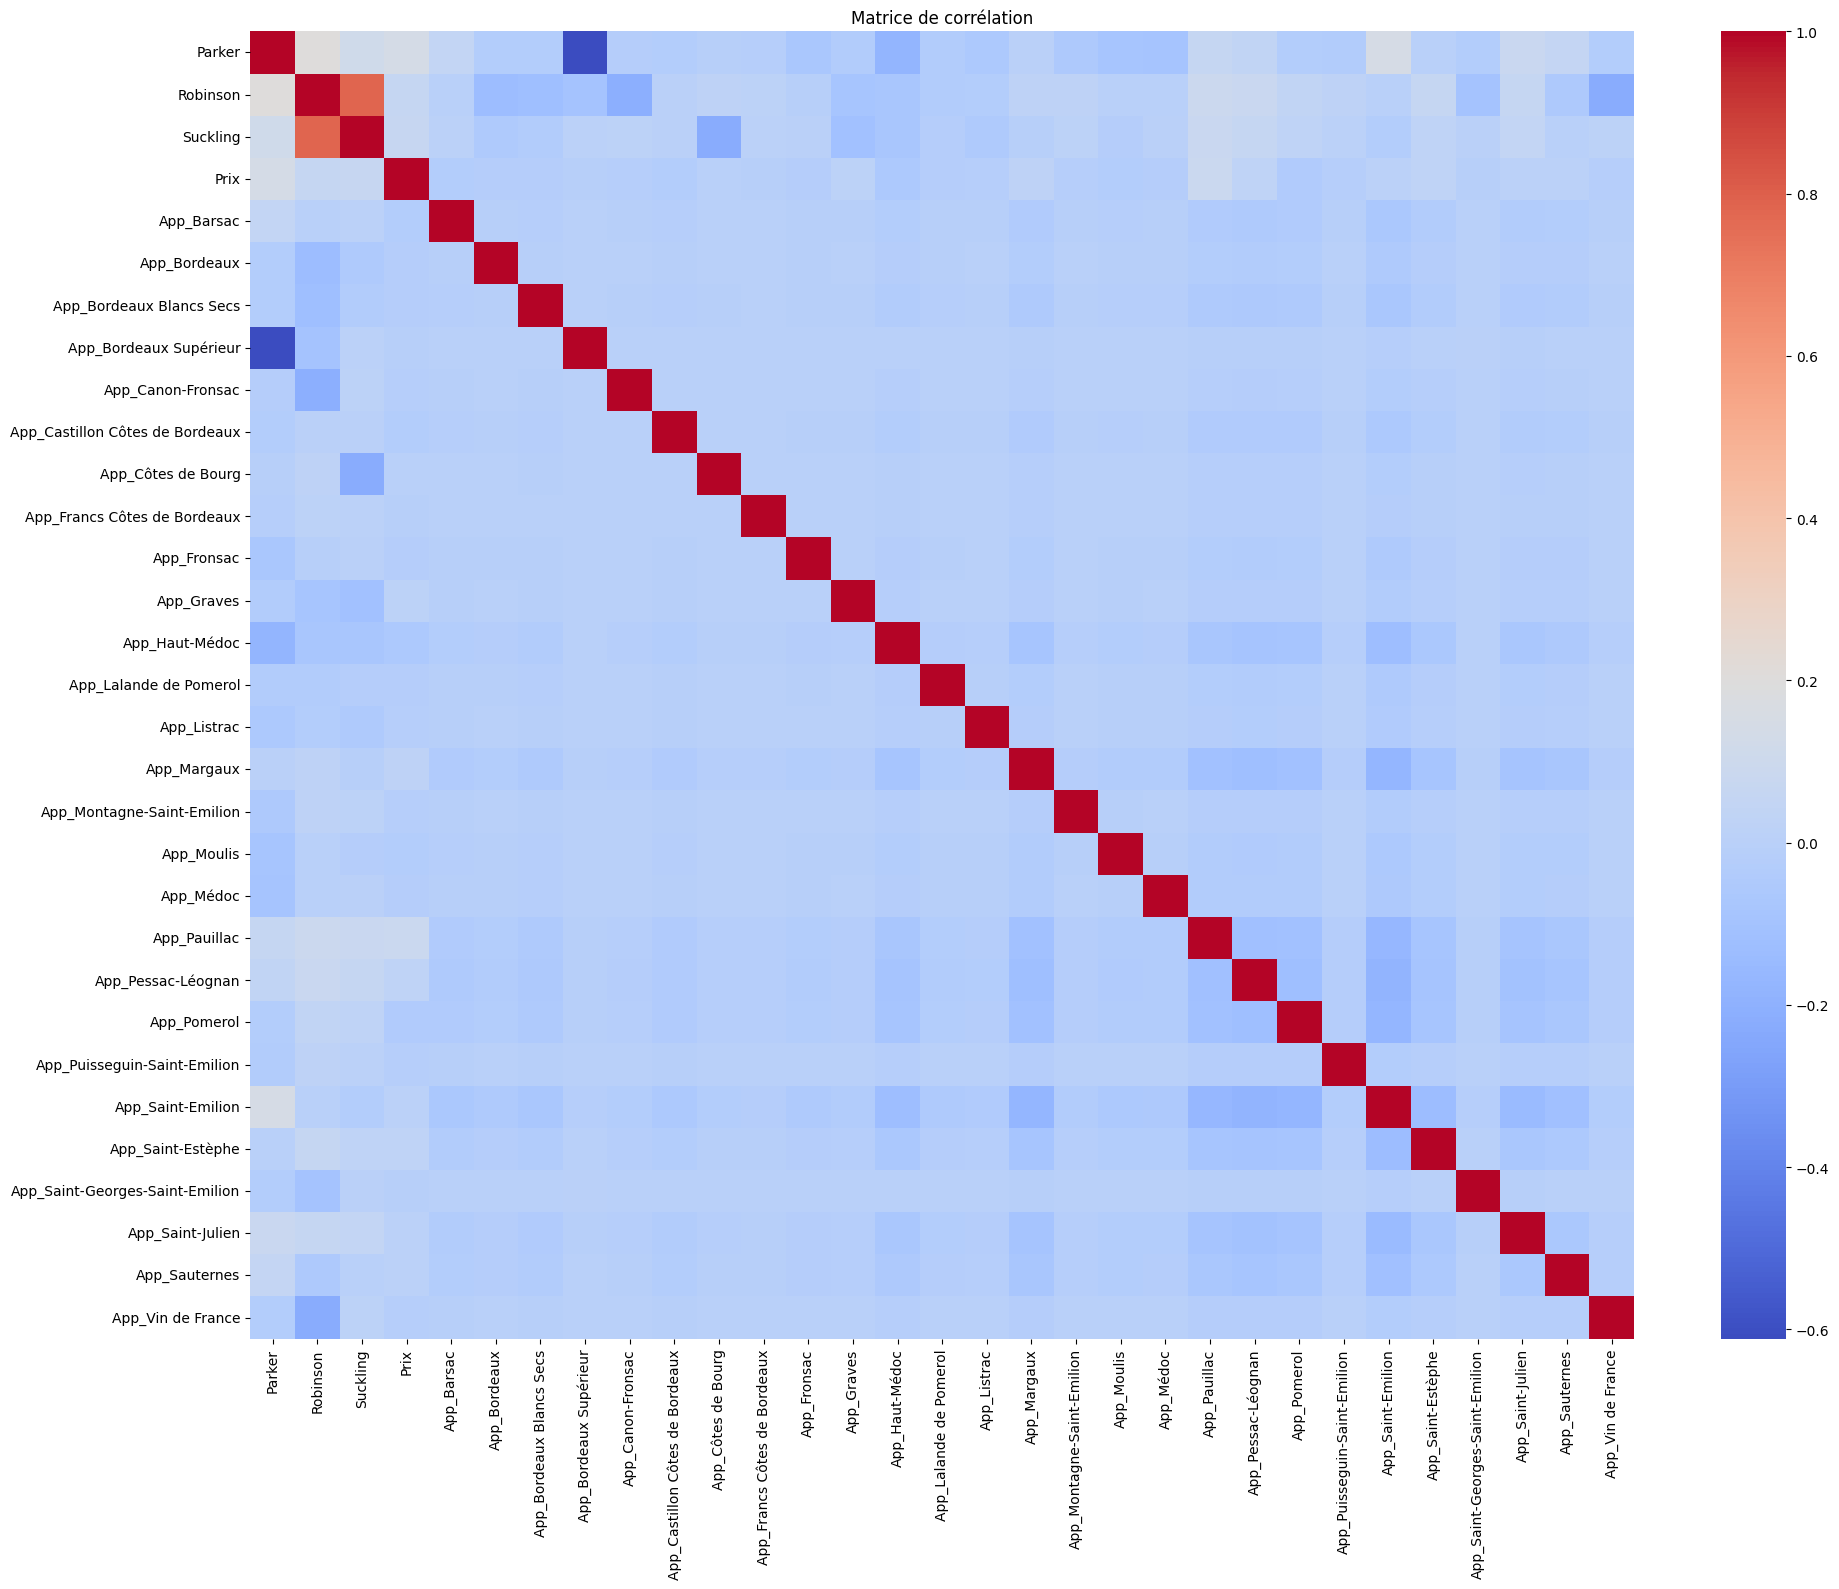

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = vins.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()
